In [1]:
import numpy as np
import pandas as pd
import os
import pathlib

from tqdm import tqdm
import warnings

from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi

from skimage.filters import median as median_filter
from skimage.morphology import square
from tifffile import imread
import tifffile
import liffile
import napari

warnings.filterwarnings("ignore")

In [2]:

lif_path = r"z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify\CART_exp1_day6.lif"

# ── helper: count cells inside/outside a region ─────────────────────────────
def _cell_counts_in_region(cell_mask, region_mask):
    labeled = label(cell_mask)
    n_total = int(labeled.max())
    if n_total == 0:
        return 0, 0, 0, 0
    props_df = pd.DataFrame(regionprops_table(labeled, properties=("centroid",)))
    rows = np.clip(np.round(props_df["centroid-0"].values).astype(int), 0, region_mask.shape[0] - 1)
    cols = np.clip(np.round(props_df["centroid-1"].values).astype(int), 0, region_mask.shape[1] - 1)
    in_region = region_mask.astype(bool)[rows, cols]
    n_in  = int(in_region.sum())
    n_out = n_total - n_in
    pix_in  = int(np.sum(cell_mask.astype(bool) & region_mask.astype(bool)))
    pix_out = int(np.sum(cell_mask.astype(bool) & ~region_mask.astype(bool)))
    return n_in, n_out, pix_in, pix_out


# ── QC figure: show segmented regions overlaid on their source channel ───────
def save_qc_figure(img_name, panels, out_dir):
    """Save a 2-row QC figure.
    panels: list of (title, raw_channel, mask) tuples.
    Top row = raw channel (gray), bottom row = mask overlaid in colour."""
    n = len(panels)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7), constrained_layout=True)
    fig.suptitle(f"Segmentation QC — {img_name}", fontsize=11, fontweight="bold")
    for col, (title, raw, mask) in enumerate(panels):
        axes[0, col].imshow(raw, cmap="gray", interpolation="none")
        axes[0, col].set_title(title, fontsize=9)
        axes[0, col].axis("off")
        axes[1, col].imshow(raw, cmap="gray", interpolation="none")
        overlay = np.zeros((*raw.shape, 4), dtype=float)
        overlay[mask, :] = [1, 0.2, 0.2, 0.5]
        axes[1, col].imshow(overlay, interpolation="none")
        axes[1, col].set_title("mask", fontsize=8)
        axes[1, col].axis("off")
    out_path = out_dir / f"{img_name.replace('/', '_')}_QC.png"
    fig.savefig(out_path, dpi=80, bbox_inches="tight")
    plt.close(fig)
    return out_path


# ── main per-image analysis function ────────────────────────────────────────
def analyse_image(img):
    """Run the full segmentation + counting pipeline on one LifImage.
    Returns (df_counts, df_distances, qc_panels).
      df_counts    — one row per (cell_type, region, location)
      df_distances — one row per cell with distance from tumour edge + region membership columns
    """
    data = img.asarray()
    z_axis = img.dims.index('Z')
    mx = np.max(data, axis=z_axis)   # shape: (C, Y, X)

    # --- segmentation ---
    vasculature_raw    = mx[3]
    vasculature_median = median_filter(vasculature_raw, footprint=square(7))
    smooth_vasc        = gaussian(vasculature_median, sigma=3)
    seg_vasculature    = smooth_vasc > threshold_triangle(smooth_vasc)

    device  = mx[1]
    clipped = np.clip(device, np.percentile(device, 25), np.percentile(device, 90))
    smoothed = gaussian(clipped, sigma=7)
    gel = util.invert(smoothed > threshold_mean(smoothed))
    gel = remove_small_holes(gel, max_size=500000)
    labeled_gel = label(gel)
    gel_props   = pd.DataFrame(regionprops_table(labeled_gel, properties=("label", "area")))
    gel = labeled_gel == gel_props.loc[gel_props["area"].idxmax(), "label"]

    # Tumour: keep largest component then fill internal holes
    tumour = device < threshold_minimum(device)
    labeled_tumour = label(tumour)
    t_props = pd.DataFrame(regionprops_table(labeled_tumour, properties=("label", "area")))
    tumour = labeled_tumour == t_props.loc[t_props["area"].idxmax(), "label"]
    tumour = remove_small_holes(tumour.astype(bool), max_size=500000)

    # Distance from tumour edge: 0 inside tumour, euclidean pixels outside
    dist_from_tumour = distance_transform_edt(~tumour)

    tcells         = mx[0]
    cart           = mx[-1]
    seg_t_cells    = tcells > threshold_yen(tcells)
    seg_cart_cells = cart   > threshold_otsu(cart)

    # Split non-gel area into left / right using the gel's horizontal centroid
    non_gel = ~gel.astype(bool)
    gel_center_col = int(np.mean(np.where(gel)[1]))
    col_idx = np.zeros_like(gel, dtype=int)
    col_idx[:, :] = np.arange(gel.shape[1])
    left_region  = non_gel & (col_idx <  gel_center_col)
    right_region = non_gel & (col_idx >= gel_center_col)

    regions = {
        "gel":         gel.astype(bool),
        "left":        left_region,
        "right":       right_region,
        "tumour":      tumour.astype(bool),
        "vasculature": seg_vasculature.astype(bool),
    }

    # panels for QC figure: (title, raw_channel_image, mask)
    qc_panels = [
        ("Gel",         device,           gel.astype(bool)),
        ("Left",        device,           left_region),
        ("Right",       device,           right_region),
        ("Tumour",      device,           tumour.astype(bool)),
        ("Vasculature", vasculature_raw,  seg_vasculature.astype(bool)),
        ("CART cells",  cart,             seg_cart_cells.astype(bool)),
        ("T cells",     tcells,           seg_t_cells.astype(bool)),
    ]

    # --- counting ---
    records = []
    dist_records = []
    for cell_name, cell_mask in [("CART cells", seg_cart_cells),
                                  ("T cells",    seg_t_cells)]:
        cell_mask = cell_mask.astype(bool)
        labeled_cells = label(cell_mask)
        n_total   = int(labeled_cells.max())
        pix_total = int(cell_mask.sum())
        records.append(dict(image=img.name, cell_type=cell_name,
                            region="overall", location="all",
                            cell_count=n_total, positive_pixels=pix_total))
        for region_name, region_mask in regions.items():
            n_in, n_out, pix_in, pix_out = _cell_counts_in_region(cell_mask, region_mask)
            records.append(dict(image=img.name, cell_type=cell_name,
                                region=region_name, location="inside",
                                cell_count=n_in,  positive_pixels=pix_in))
            records.append(dict(image=img.name, cell_type=cell_name,
                                region=region_name, location="outside",
                                cell_count=n_out, positive_pixels=pix_out))

        # Per-cell distance from tumour edge + region membership
        if n_total > 0:
            cprops = pd.DataFrame(regionprops_table(labeled_cells, properties=("centroid",)))
            crow = np.clip(np.round(cprops["centroid-0"].values).astype(int), 0, dist_from_tumour.shape[0] - 1)
            ccol = np.clip(np.round(cprops["centroid-1"].values).astype(int), 0, dist_from_tumour.shape[1] - 1)
            dists = dist_from_tumour[crow, ccol]
            for r, c, d in zip(crow, ccol, dists):
                rec = dict(image=img.name, cell_type=cell_name, distance_from_tumour=float(d))
                for region_name, region_mask in regions.items():
                    rec[f"in_{region_name}"] = bool(region_mask[r, c])
                dist_records.append(rec)

    return pd.DataFrame(records), pd.DataFrame(dist_records), qc_panels


In [3]:

all_records  = []
dist_records = []

qc_dir = pathlib.Path(lif_path).parent / "QC_figures"
qc_dir.mkdir(exist_ok=True)

with liffile.LifFile(lif_path) as lif:
    n_images = len(lif.images)
    print(f"Found {n_images} images in LIF — QC figures → {qc_dir}")
    for idx, img in enumerate(lif.images):
        print(f"  [{idx+1}/{n_images}] Processing: {img.name} {img.shape} ...")
        df_counts, df_dists, qc_panels = analyse_image(img)
        all_records.append(df_counts)
        dist_records.append(df_dists)
        out_path = save_qc_figure(img.name, qc_panels, qc_dir)
        print(f"           QC saved → {out_path.name}")

all_results   = pd.concat(all_records,  ignore_index=True)
all_distances = pd.concat(dist_records, ignore_index=True)

# Save both CSVs next to the LIF file
out_csv  = pathlib.Path(lif_path).with_suffix(".csv")
dist_csv = pathlib.Path(lif_path).with_name(pathlib.Path(lif_path).stem + "_distances.csv")
all_results.to_csv(out_csv,   index=False)
all_distances.to_csv(dist_csv, index=False)
print(f"\nCounts   → {out_csv}  ({len(all_results)} rows)")
print(f"Distances → {dist_csv}  ({len(all_distances)} rows)")
all_results


Found 8 images in LIF — QC figures → z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify\QC_figures
  [1/8] Processing: FL12_day6_ARi1 (5, 33, 2780, 4752) ...
           QC saved → FL12_day6_ARi1_QC.png
  [2/8] Processing: FL12_day6_UTD1 (5, 33, 2780, 4752) ...
           QC saved → FL12_day6_UTD1_QC.png
  [3/8] Processing: FL12_day6_ARi2 (5, 40, 2784, 4749) ...
           QC saved → FL12_day6_ARi2_QC.png
  [4/8] Processing: FL12_day6_UTD2 (5, 38, 2782, 4749) ...
           QC saved → FL12_day6_UTD2_QC.png
  [5/8] Processing: FL12_day6_ARi3 (5, 42, 2782, 4747) ...
           QC saved → FL12_day6_ARi3_QC.png
  [6/8] Processing: FL12_day6_UTD3 (5, 36, 2783, 4748) ...
           QC saved → FL12_day6_UTD3_QC.png
  [7/8] Processing: FL12_day6_ARi4 (5, 34, 2782, 4748) ...
           QC saved → FL12_day6_ARi4_QC.png
  [8/8] Processing: OUT-FL12_day6_UTD4 (5, 40, 2780, 4746) ...
           QC saved → OUT-FL12_day6_UTD4_QC.png

Counts   → z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQua

,image,cell_type,region,location,cell_count,positive_pixels
0,FL12_day6_ARi1,CART cells,overall,all,9349,117651
1,FL12_day6_ARi1,CART cells,gel,inside,1640,18236
2,FL12_day6_ARi1,CART cells,gel,outside,7709,99415
3,FL12_day6_ARi1,CART cells,left,inside,3418,44314
4,FL12_day6_ARi1,CART cells,left,outside,5931,73337
...,...,...,...,...,...,...
171,OUT-FL12_day6_UTD4,T cells,right,outside,726,1125
172,OUT-FL12_day6_UTD4,T cells,tumour,inside,59,198
173,OUT-FL12_day6_UTD4,T cells,tumour,outside,748,1057
174,OUT-FL12_day6_UTD4,T cells,vasculature,inside,698,1060


In [4]:

all_results.head(20)


,image,cell_type,region,location,cell_count,positive_pixels
0,FL12_day6_ARi1,CART cells,overall,all,9349,117651
1,FL12_day6_ARi1,CART cells,gel,inside,1640,18236
2,FL12_day6_ARi1,CART cells,gel,outside,7709,99415
3,FL12_day6_ARi1,CART cells,left,inside,3418,44314
4,FL12_day6_ARi1,CART cells,left,outside,5931,73337
5,FL12_day6_ARi1,CART cells,right,inside,4291,55101
6,FL12_day6_ARi1,CART cells,right,outside,5058,62550
7,FL12_day6_ARi1,CART cells,tumour,inside,19,96
8,FL12_day6_ARi1,CART cells,tumour,outside,9330,117555
9,FL12_day6_ARi1,CART cells,vasculature,inside,5947,72319


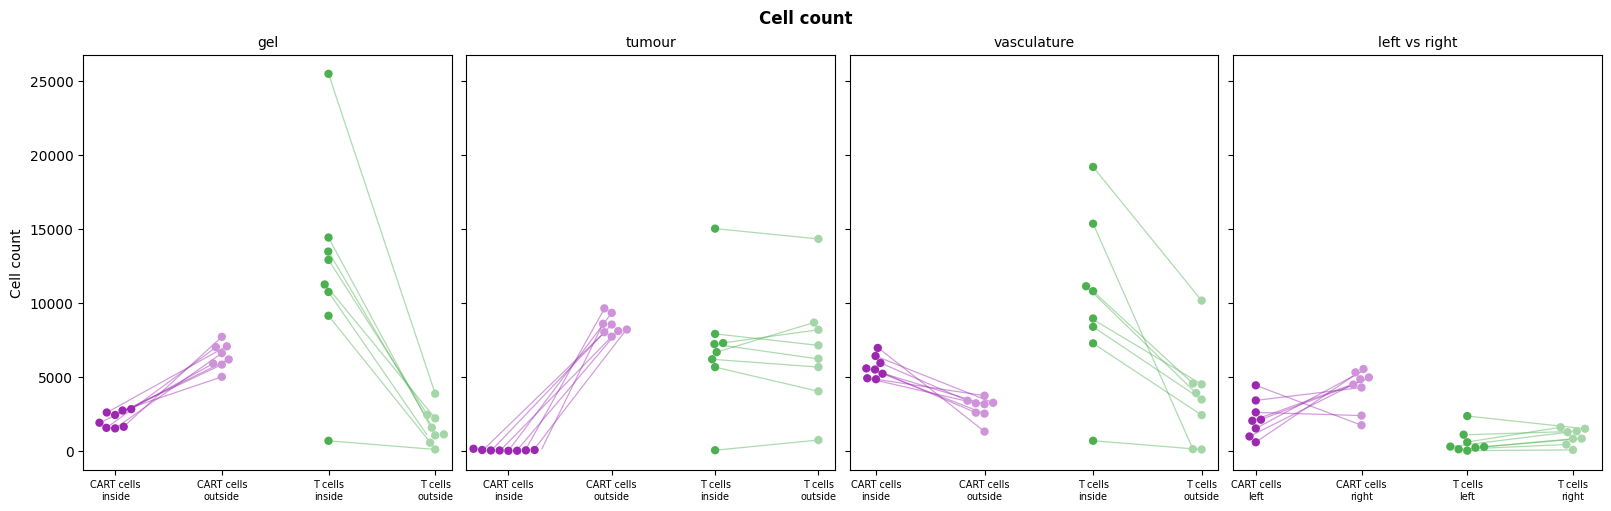

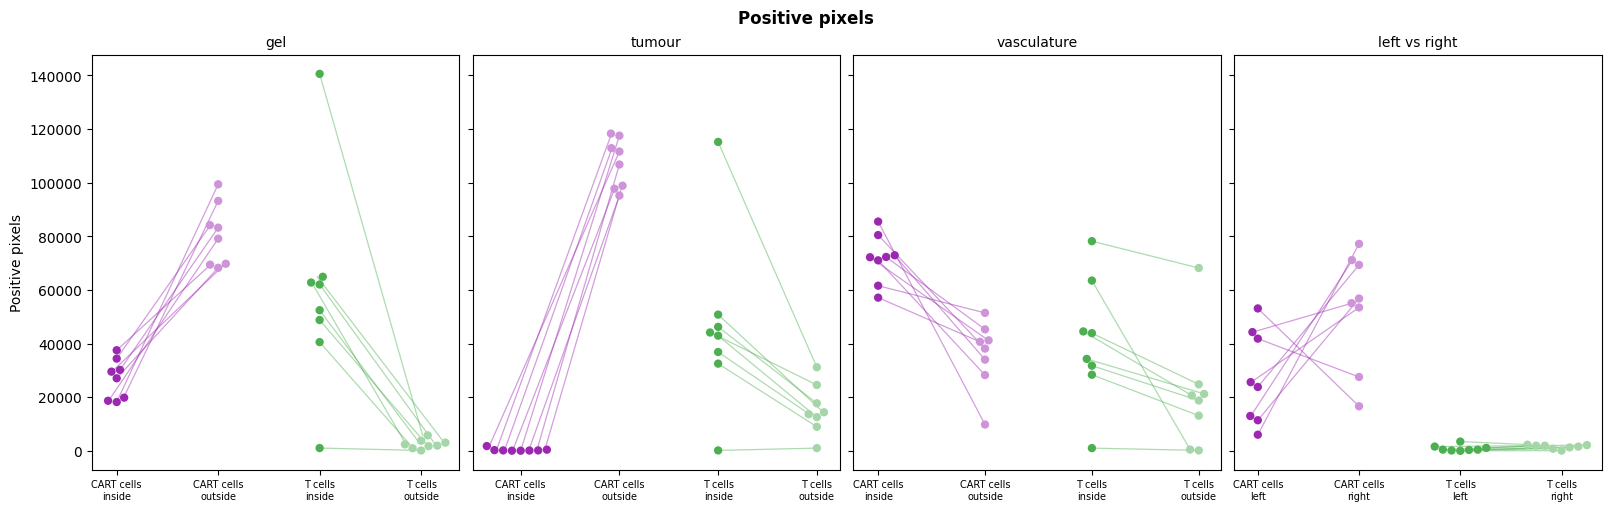

In [5]:

# ── Swarmplots: all images combined, one panel per region ────────────────────
import seaborn as sns

# Standard regions: 4 groups each (cell type × inside/outside)
standard_regions = ["gel", "tumour", "vasculature"]

in_out_palette = {
    "CART cells\ninside":  "#9C27B0",
    "CART cells\noutside": "#CE93D8",
    "T cells\ninside":     "#4CAF50",
    "T cells\noutside":    "#A5D6A7",
}
in_out_order = list(in_out_palette.keys())
in_out_pairs = [
    ("CART cells\ninside", "CART cells\noutside", "#9C27B0"),
    ("T cells\ninside",    "T cells\noutside",    "#4CAF50"),
]

# Left vs right panel: 4 groups (cell type × left/right)
lr_palette = {
    "CART cells\nleft":  "#9C27B0",
    "CART cells\nright": "#CE93D8",
    "T cells\nleft":     "#4CAF50",
    "T cells\nright":    "#A5D6A7",
}
lr_order = list(lr_palette.keys())
lr_pairs = [
    ("CART cells\nleft", "CART cells\nright", "#9C27B0"),
    ("T cells\nleft",    "T cells\nright",    "#4CAF50"),
]

metrics = [("cell_count", "Cell count"), ("positive_pixels", "Positive pixels")]

def _draw_pair_lines(ax, colls, order, pairs, sub):
    for in_grp, out_grp, line_color in pairs:
        in_idx  = order.index(in_grp)
        out_idx = order.index(out_grp)
        if in_idx >= len(colls) or out_idx >= len(colls):
            continue
        in_pts  = colls[in_idx].get_offsets()
        out_pts = colls[out_idx].get_offsets()
        in_df  = sub[sub.group == in_grp].reset_index(drop=True)
        out_df = sub[sub.group == out_grp].reset_index(drop=True)
        for i, img_name in enumerate(in_df["image"]):
            if i >= len(in_pts):
                continue
            j_list = out_df.index[out_df["image"] == img_name].tolist()
            if not j_list or j_list[0] >= len(out_pts):
                continue
            j = j_list[0]
            ax.plot([in_pts[i, 0], out_pts[j, 0]],
                    [in_pts[i, 1], out_pts[j, 1]],
                    color=line_color, lw=0.9, alpha=0.45, zorder=0)

n_panels = len(standard_regions) + 1  # +1 for left vs right

for metric, ylabel in metrics:
    # Build standard region data
    std_frames = []
    for region in standard_regions:
        sub = all_results[
            (all_results.region == region) &
            (all_results.location.isin(["inside", "outside"]))
        ].copy()
        sub["group"] = sub["cell_type"] + "\n" + sub["location"]
        sub["panel"] = region
        std_frames.append(sub)
    std_df = pd.concat(std_frames, ignore_index=True)

    # Build left vs right data
    lr_frames = []
    for side in ["left", "right"]:
        sub = all_results[
            (all_results.region == side) &
            (all_results.location == "inside")
        ].copy()
        sub["group"] = sub["cell_type"] + "\n" + side
        sub["panel"] = "left vs right"
        lr_frames.append(sub)
    lr_df = pd.concat(lr_frames, ignore_index=True)

    fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 5),
                             sharey=True, constrained_layout=True)
    fig.suptitle(ylabel, fontsize=12, fontweight="bold")

    for ax, region in zip(axes[:len(standard_regions)], standard_regions):
        sub = std_df[std_df.panel == region]
        sns.swarmplot(data=sub, x="group", y=metric, palette=in_out_palette,
                      order=in_out_order, size=6, ax=ax)
        _draw_pair_lines(ax, ax.collections, in_out_order, in_out_pairs, sub)
        ax.set_title(region, fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel if ax is axes[0] else "")
        ax.tick_params(axis="x", labelsize=7)

    # Left vs right panel
    ax_lr = axes[-1]
    sns.swarmplot(data=lr_df, x="group", y=metric, palette=lr_palette,
                  order=lr_order, size=6, ax=ax_lr)
    _draw_pair_lines(ax_lr, ax_lr.collections, lr_order, lr_pairs, lr_df)
    ax_lr.set_title("left vs right", fontsize=10)
    ax_lr.set_xlabel("")
    ax_lr.set_ylabel("")
    ax_lr.tick_params(axis="x", labelsize=7)

    # plt.savefig(f"outputs_{metric}.png")


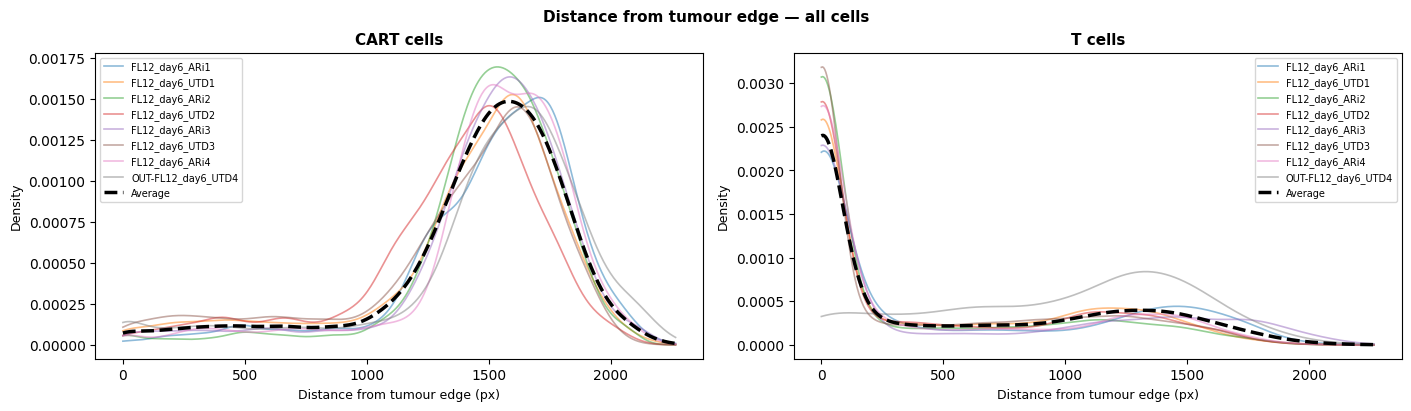

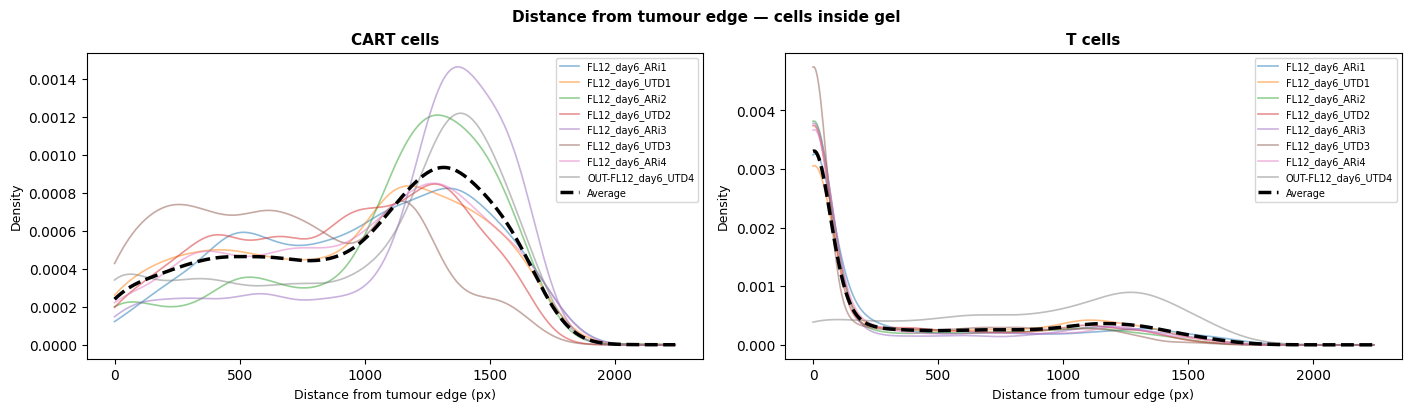

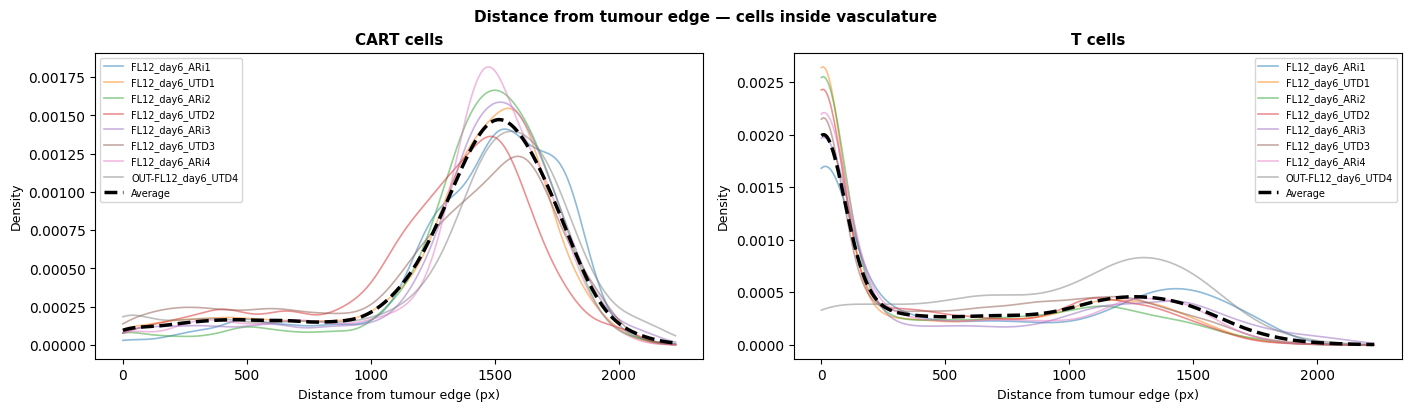

In [6]:

# ── Distance from tumour edge — KDE plots ────────────────────────────────────
import seaborn as sns
from scipy.stats import gaussian_kde

def plot_distance_kde(df, title_suffix=""):
    """KDE of distance-from-tumour per cell type.
    Each image gets a faded coloured line; the average across images is dashed black."""
    if df.empty:
        print(f"No data for{title_suffix} — skipping.")
        return
    cell_types  = df["cell_type"].unique()
    images      = df["image"].unique()
    img_palette = sns.color_palette("tab10", n_colors=len(images))
    img_color   = {img: col for img, col in zip(images, img_palette)}

    fig, axes = plt.subplots(1, len(cell_types), figsize=(7 * len(cell_types), 4),
                             sharey=False, constrained_layout=True)
    if len(cell_types) == 1:
        axes = [axes]

    x_grid = np.linspace(0, df["distance_from_tumour"].max(), 500)

    for ax, ct in zip(axes, cell_types):
        sub_ct = df[df["cell_type"] == ct]
        all_densities = []
        for img_name in images:
            vals = sub_ct[sub_ct["image"] == img_name]["distance_from_tumour"].values
            if len(vals) < 2:
                continue
            kde = gaussian_kde(vals)
            y   = kde(x_grid)
            ax.plot(x_grid, y, color=img_color[img_name], alpha=0.5, linewidth=1.2, label=img_name)
            all_densities.append(y)
        if all_densities:
            avg_y = np.mean(all_densities, axis=0)
            ax.plot(x_grid, avg_y, color="black", linewidth=2.5, linestyle="--", label="Average")
        ax.set_title(ct, fontsize=11, fontweight="bold")
        ax.set_xlabel("Distance from tumour edge (px)", fontsize=9)
        ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=7, ncol=1)

    fig.suptitle(f"Distance from tumour edge{title_suffix}",
                 fontsize=11, fontweight="bold")
    plt.show()


plot_distance_kde(all_distances, " — all cells")

has_region_cols = "in_gel" in all_distances.columns

if has_region_cols:
    plot_distance_kde(all_distances[all_distances["in_gel"]],
                      " — cells inside gel")
    plot_distance_kde(all_distances[all_distances["in_vasculature"]],
                      " — cells inside vasculature")
else:
    print("Region columns (in_gel, in_vasculature, …) not found in all_distances.\n"
          "Re-run cell 2 then cell 3 to regenerate all_distances with region membership.")


In [7]:

# ── Colocalisation analysis ───────────────────────────────────────────────────
# Method 1: Coarse-grained Pearson r (Gaussian-blurred channels, several σ)
# Method 2: Binary proximity fraction using EDT (several radii)
# Both computed for: whole image, gel, tumour, vasculature
# Scales are specified in micrometres; pixel size is read from LIF metadata.
# ─────────────────────────────────────────────────────────────────────────────
from scipy import stats as _stats

# Physical scales to test (micrometres)
gauss_sigmas_um    = [5, 10, 20, 50, 100]
proximity_radii_um = [5, 10, 20, 50, 100]

coloc_records = []

with liffile.LifFile(lif_path) as lif:
    for img in lif.images:
        # ── pixel size ──────────────────────────────────────────────────────
        try:
            um_per_px = float(img.scale["X"]) * 1e6   # metres → µm
            if um_per_px <= 0:
                raise ValueError
        except Exception:
            um_per_px = 1.0
            print(f"  Warning: could not read pixel size for {img.name}, using 1 µm/px")
        print(f"  {img.name}: {um_per_px:.4f} µm/px")

        # ── max projection ──────────────────────────────────────────────────
        data   = img.asarray()
        z_axis = img.dims.index("Z")
        mx     = np.max(data, axis=z_axis)    # (C, Y, X)

        tcell_ch = mx[0].astype(float)
        cart_ch  = mx[-1].astype(float)
        device   = mx[1]
        vasc_raw = mx[3]

        # ── re-run segmentation (same as analyse_image) ─────────────────────
        clipped  = np.clip(device, np.percentile(device, 25), np.percentile(device, 90))
        smoothed = gaussian(clipped, sigma=7)
        gel_mask = util.invert(smoothed > threshold_mean(smoothed))
        gel_mask = remove_small_holes(gel_mask, max_size=500000)
        lbl_gel  = label(gel_mask)
        gp       = pd.DataFrame(regionprops_table(lbl_gel, properties=("label", "area")))
        gel_mask = (lbl_gel == gp.loc[gp["area"].idxmax(), "label"]).astype(bool)

        tumour_mask = device < threshold_minimum(device)
        lbl_t       = label(tumour_mask)
        tp          = pd.DataFrame(regionprops_table(lbl_t, properties=("label", "area")))
        tumour_mask = (lbl_t == tp.loc[tp["area"].idxmax(), "label"]).astype(bool)
        tumour_mask = remove_small_holes(tumour_mask, max_size=500000)

        vasc_med  = median_filter(vasc_raw, footprint=square(7))
        vasc_sm   = gaussian(vasc_med, sigma=3)
        vasc_mask = (vasc_sm > threshold_triangle(vasc_sm)).astype(bool)

        seg_t    = tcell_ch > threshold_yen(tcell_ch)
        seg_cart = cart_ch  > threshold_otsu(cart_ch)

        region_masks = {
            "whole_image": np.ones(mx.shape[1:], dtype=bool),
            "gel":         gel_mask,
            "tumour":      tumour_mask,
            "vasculature": vasc_mask,
        }

        # ── Method 1: Coarse-grained Pearson (Gaussian blur) ────────────────
        for sigma_um in gauss_sigmas_um:
            sigma_px = sigma_um / um_per_px
            t_blur   = gaussian(tcell_ch, sigma=sigma_px)
            c_blur   = gaussian(cart_ch,  sigma=sigma_px)
            for region_name, rmask in region_masks.items():
                t_vals = t_blur[rmask]
                c_vals = c_blur[rmask]
                if len(t_vals) < 20:
                    r = np.nan
                else:
                    r, _ = _stats.pearsonr(t_vals, c_vals)
                coloc_records.append(dict(
                    image=img.name, method="coarse_pearson",
                    param_um=sigma_um, region=region_name, score=float(r),
                ))

        # ── Method 2: Binary proximity fraction (EDT) ────────────────────────
        # EDT gives distance (pixels) from each background pixel to nearest foreground pixel
        cart_dist = distance_transform_edt(~seg_cart.astype(bool))
        t_dist    = distance_transform_edt(~seg_t.astype(bool))

        for radius_um in proximity_radii_um:
            radius_px    = radius_um / um_per_px
            cart_within  = cart_dist <= radius_px   # True where a CART cell is within radius
            t_within     = t_dist    <= radius_px   # True where a T cell is within radius

            for region_name, rmask in region_masks.items():
                # fraction of T-cell pixels (in region) within radius of a CART cell
                t_in   = seg_t.astype(bool) & rmask
                n_t    = int(t_in.sum())
                frac_t = float((t_in & cart_within).sum()) / n_t if n_t > 0 else np.nan

                # fraction of CART-cell pixels (in region) within radius of a T cell
                c_in   = seg_cart.astype(bool) & rmask
                n_c    = int(c_in.sum())
                frac_c = float((c_in & t_within).sum()) / n_c if n_c > 0 else np.nan

                coloc_records.append(dict(
                    image=img.name, method="T_near_CART",
                    param_um=radius_um, region=region_name, score=frac_t,
                ))
                coloc_records.append(dict(
                    image=img.name, method="CART_near_T",
                    param_um=radius_um, region=region_name, score=frac_c,
                ))

coloc_df = pd.DataFrame(coloc_records)

# Save
coloc_csv = pathlib.Path(lif_path).with_name(pathlib.Path(lif_path).stem + "_colocalisation.csv")
coloc_df.to_csv(coloc_csv, index=False)
print(f"\nSaved → {coloc_csv}  ({len(coloc_df)} rows)")
coloc_df.head(20)


  FL12_day6_ARi1: 1.0000 µm/px
  FL12_day6_UTD1: 1.0000 µm/px
  FL12_day6_ARi2: 1.0000 µm/px
  FL12_day6_UTD2: 1.0000 µm/px
  FL12_day6_ARi3: 1.0000 µm/px
  FL12_day6_UTD3: 1.0000 µm/px
  FL12_day6_ARi4: 1.0000 µm/px
  OUT-FL12_day6_UTD4: 1.0000 µm/px

Saved → z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify\CART_exp1_day6_colocalisation.csv  (480 rows)


,image,method,param_um,region,score
0,FL12_day6_ARi1,coarse_pearson,5,whole_image,0.206110
1,FL12_day6_ARi1,coarse_pearson,5,gel,0.344662
2,FL12_day6_ARi1,coarse_pearson,5,tumour,0.247030
3,FL12_day6_ARi1,coarse_pearson,5,vasculature,0.169103
4,FL12_day6_ARi1,coarse_pearson,10,whole_image,0.234865
5,FL12_day6_ARi1,coarse_pearson,10,gel,0.426359
6,FL12_day6_ARi1,coarse_pearson,10,tumour,0.276217
7,FL12_day6_ARi1,coarse_pearson,10,vasculature,0.195254
8,FL12_day6_ARi1,coarse_pearson,20,whole_image,0.237371
9,FL12_day6_ARi1,coarse_pearson,20,gel,0.469102


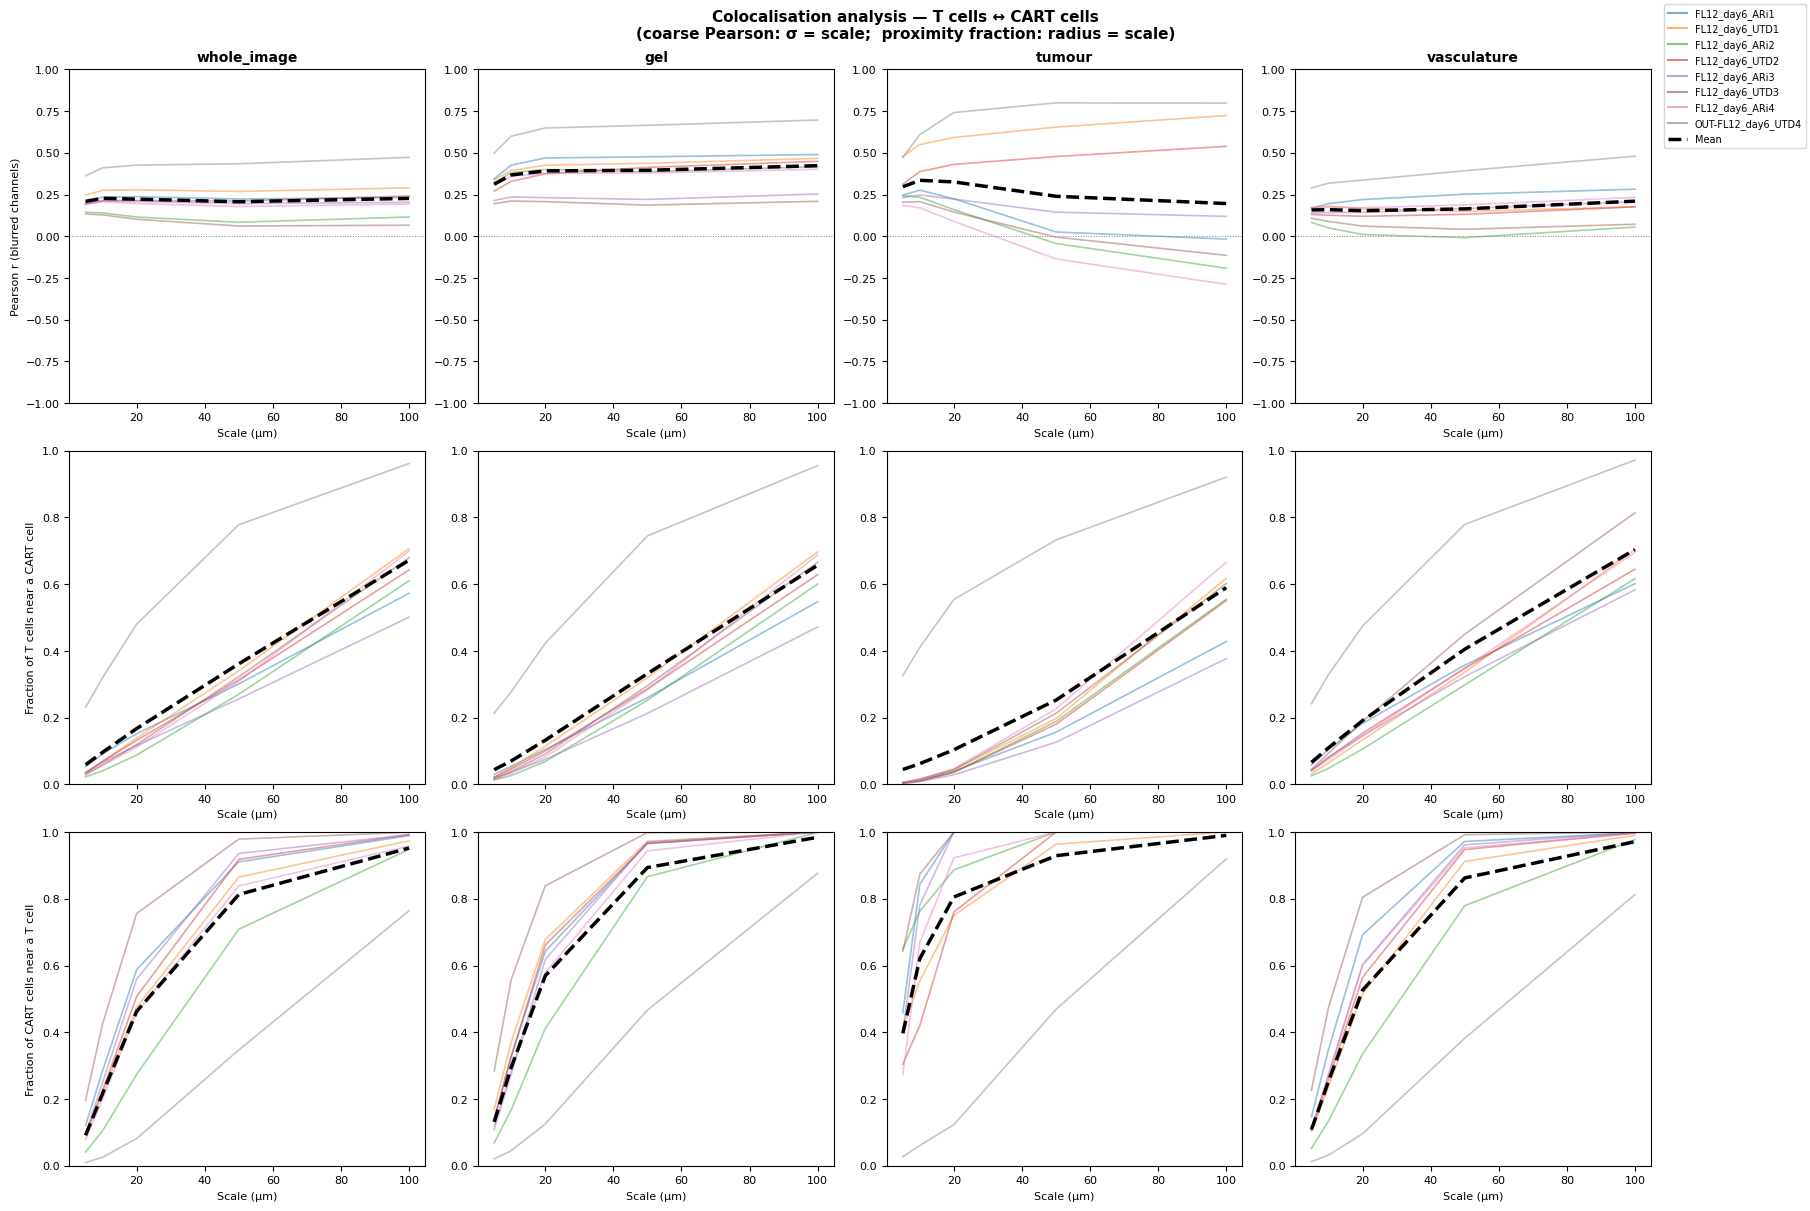

In [8]:

# ── Colocalisation plots ──────────────────────────────────────────────────────
import seaborn as sns

methods      = ["coarse_pearson", "T_near_CART", "CART_near_T"]
ylabels      = {
    "coarse_pearson": "Pearson r (blurred channels)",
    "T_near_CART":    "Fraction of T cells near a CART cell",
    "CART_near_T":    "Fraction of CART cells near a T cell",
}
region_order = ["whole_image", "gel", "tumour", "vasculature"]
images       = coloc_df["image"].unique()
img_palette  = sns.color_palette("tab10", n_colors=len(images))
img_color    = {name: col for name, col in zip(images, img_palette)}

n_rows = len(methods)
n_cols = len(region_order)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4.5 * n_cols, 4 * n_rows),
                         constrained_layout=True)
fig.suptitle("Colocalisation analysis — T cells ↔ CART cells\n"
             "(coarse Pearson: σ = scale;  proximity fraction: radius = scale)",
             fontsize=11, fontweight="bold")

for row, method in enumerate(methods):
    sub_m = coloc_df[coloc_df.method == method]
    for col, region in enumerate(region_order):
        ax  = axes[row, col]
        sub = sub_m[sub_m.region == region].copy()

        # one faded line per image
        for img_name in images:
            s = sub[sub.image == img_name].sort_values("param_um")
            ax.plot(s["param_um"], s["score"],
                    color=img_color[img_name], alpha=0.45, linewidth=1.2)

        # mean line across images
        mean_s = sub.groupby("param_um")["score"].mean().reset_index()
        ax.plot(mean_s["param_um"], mean_s["score"],
                color="black", linewidth=2.5, linestyle="--", label="Mean")

        if method == "coarse_pearson":
            ax.axhline(0, color="gray", linewidth=0.7, linestyle=":")
            ax.set_ylim(-1, 1)
        else:
            ax.set_ylim(0, 1)

        if row == 0:
            ax.set_title(region, fontsize=10, fontweight="bold")
        ax.set_xlabel("Scale (µm)", fontsize=8)
        ax.set_ylabel(ylabels[method] if col == 0 else "", fontsize=8)
        ax.tick_params(labelsize=8)

# Legend
handles = [plt.Line2D([0], [0], color=img_color[n], linewidth=1.5,
                       alpha=0.6, label=n) for n in images]
handles.append(plt.Line2D([0], [0], color="black", linewidth=2.5,
                           linestyle="--", label="Mean"))
fig.legend(handles=handles, loc="outside right upper", fontsize=7, ncol=1)
plt.show()
